# Store Item Demand Forecasting
Dataset: Montgomery County Warehouse & Retail Sales (real, monthly, item-level).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)


## 1. Load & Inspect

In [2]:
df = pd.read_csv("Warehouse_and_Retail_Sales.csv")
print(df.shape)
df.head()


(330080, 9)


,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
0,2026,7,20705 IMPORTS,180424,FENTO BICO DA RAN ALBARINO 750ML,WINE,0.00,0.00,1.00
1,2026,7,20705 IMPORTS,246789,MIHOVI EST BROAD LEAVED MELNIK - 750ML,WINE,0.00,0.00,1.00
2,2026,7,20705 IMPORTS,180113,DOM DU FOURNIER SIGNARGUES CDR VILLAGES 750ML,WINE,0.00,0.00,1.00
3,2026,7,20705 IMPORTS,180298,AGRICOLA LA PORTERA TARDANO GARNACHA 750ML,WINE,0.00,0.00,1.00
4,2026,7,20705 IMPORTS,246788,MIHOVI EST KERASTUDA SEL KEPAUYDA - 750ML,WINE,0.00,0.00,1.00


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 330080 entries, 0 to 330079
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   YEAR              330080 non-null  int64 
 1   MONTH             330080 non-null  int64 
 2   SUPPLIER          329887 non-null  object
 3   ITEM CODE         330080 non-null  object
 4   ITEM DESCRIPTION  330080 non-null  object
 5   ITEM TYPE         330079 non-null  object
 6   RETAIL SALES      330075 non-null  object
 7   RETAIL TRANSFERS  330080 non-null  object
 8   WAREHOUSE SALES   330080 non-null  object
dtypes: int64(2), object(7)
memory usage: 22.7+ MB


In [4]:
print("Missing values:\n", df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nYears:", sorted(df['YEAR'].unique()))
print("\nItem types:", df['ITEM TYPE'].unique())


Missing values:
 YEAR                  0
MONTH                 0
SUPPLIER            193
ITEM CODE             0
ITEM DESCRIPTION      0
ITEM TYPE             1
RETAIL SALES          5
RETAIL TRANSFERS      0
WAREHOUSE SALES       0
dtype: int64

Duplicate rows: 0

Years: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2026)]

Item types: ['WINE' 'LIQUOR' 'BEER' 'KEGS' 'NON-ALCOHOL' 'DUNNAGE' 'STR_SUPPLIES'
 'REF' nan]


## 2. Cleaning

In [5]:
def clean_numeric(series):
    s = series.astype(str).str.strip()
    s = s.str.replace(",", "", regex=False)
    neg_mask = s.str.startswith("(") & s.str.endswith(")")
    s = s.str.replace(r"[()]", "", regex=True)
    s = pd.to_numeric(s, errors="coerce")
    s[neg_mask] = -s[neg_mask].abs()
    return s

for col in ["RETAIL SALES", "RETAIL TRANSFERS", "WAREHOUSE SALES"]:
    df[col] = clean_numeric(df[col])

df[["RETAIL SALES", "RETAIL TRANSFERS", "WAREHOUSE SALES"]] = df[["RETAIL SALES", "RETAIL TRANSFERS", "WAREHOUSE SALES"]].fillna(0)


In [6]:
df["SUPPLIER"] = df["SUPPLIER"].astype(str).str.strip().str.upper()
df["SUPPLIER"] = df["SUPPLIER"].replace("NAN", np.nan)
df["SUPPLIER"] = df["SUPPLIER"].fillna("UNKNOWN SUPPLIER")

df["ITEM DESCRIPTION"] = df["ITEM DESCRIPTION"].astype(str).str.strip().str.upper()
df["ITEM TYPE"] = df["ITEM TYPE"].astype(str).str.strip().str.upper()
df["ITEM TYPE"] = df["ITEM TYPE"].replace("NAN", "UNKNOWN")

df = df[df["ITEM TYPE"].isin(["WINE", "LIQUOR", "BEER", "KEGS", "NON-ALCOHOL"])]

df["DATE"] = pd.to_datetime(df["YEAR"].astype(str) + "-" + df["MONTH"].astype(str) + "-01")

df["TOTAL SALES"] = df["RETAIL SALES"] + df["WAREHOUSE SALES"]

df = df.drop_duplicates()
print(df.shape)
df.head()


(329394, 11)


,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES,DATE,TOTAL SALES
0,2026,7,20705 IMPORTS,180424,FENTO BICO DA RAN ALBARINO 750ML,WINE,0.0,0.0,1.0,2026-07-01,1.0
1,2026,7,20705 IMPORTS,246789,MIHOVI EST BROAD LEAVED MELNIK - 750ML,WINE,0.0,0.0,1.0,2026-07-01,1.0
2,2026,7,20705 IMPORTS,180113,DOM DU FOURNIER SIGNARGUES CDR VILLAGES 750ML,WINE,0.0,0.0,1.0,2026-07-01,1.0
3,2026,7,20705 IMPORTS,180298,AGRICOLA LA PORTERA TARDANO GARNACHA 750ML,WINE,0.0,0.0,1.0,2026-07-01,1.0
4,2026,7,20705 IMPORTS,246788,MIHOVI EST KERASTUDA SEL KEPAUYDA - 750ML,WINE,0.0,0.0,1.0,2026-07-01,1.0


## 3. Aggregation to Item-Level Monthly Demand

In [7]:
item_monthly = (
    df.groupby(["ITEM CODE", "ITEM DESCRIPTION", "ITEM TYPE", "DATE"], as_index=False)
    .agg(TOTAL_SALES=("TOTAL SALES", "sum"))
)
item_monthly = item_monthly.sort_values(["ITEM CODE", "DATE"])
print(item_monthly.shape)
item_monthly.head()


(329394, 5)


,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,DATE,TOTAL_SALES
0,100002,PATRON TEQUILA SILVER LTD - 1L,LIQUOR,2017-07-01,0.17
1,100007,LA CETTO CAB SAUV - 750ML,WINE,2019-04-01,1.00
2,100007,LA CETTO CAB SAUV - 750ML,WINE,2019-05-01,1.00
3,100007,LA CETTO CAB SAUV - 750ML,WINE,2019-10-01,1.00
4,100007,LA CETTO CAB SAUV - 750ML,WINE,2019-11-01,1.00


In [8]:
item_totals = item_monthly.groupby(["ITEM CODE", "ITEM DESCRIPTION", "ITEM TYPE"])["TOTAL_SALES"].sum().sort_values(ascending=False)
item_totals.head(15)


ITEM CODE  ITEM DESCRIPTION                      ITEM TYPE
23445      CORONA EXTRA LOOSE NR - 12OZ          BEER         353028.68
96750      CORONA EXTRA 2/12 NR - 12OZ           BEER         273862.29
23886      HEINEKEN LOOSE NR - 12OZ              BEER         200514.00
96970      HEINEKEN 2/12 NR - 12OZ               BEER         171243.90
90590      MILLER LITE 30PK CAN - 12OZ           BEER         158497.27
96741      CORONA EXTRA 4/6 NR - 12OZ            BEER         140960.51
25883      MODELO ESPECIAL 24 LOOSE NR - 12OZ    BEER         137822.60
95800      MODELO ESPECIAL-2/12 CAN - 12OZ       BEER         113257.09
90468      BUD LIGHT 30PK CAN                    BEER         112816.71
23777      MODELO ESPECIAL SUITCASE CANS - 12OZ  BEER         111007.72
96083      HEINEKEN 4/6 NR - 12OZ                BEER         110841.13
99198      MODELO ESPECIAL 2/12 NR - 12OZ        BEER         108183.39
23314      CORONA EXTRA 18PK NR - 12OZ           BEER         106756.77
91170

In [9]:
N_ITEMS = 15
top_items = item_totals.head(N_ITEMS).reset_index()["ITEM CODE"].tolist()
print(top_items)


['23445', '96750', '23886', '96970', '90590', '96741', '25883', '95800', '90468', '23777', '96083', '99198', '23314', '91170', '23318']


In [10]:
full_range = pd.date_range(item_monthly["DATE"].min(), item_monthly["DATE"].max(), freq="MS")

series_dict = {}
for code_ in top_items:
    sub = item_monthly[item_monthly["ITEM CODE"] == code_].set_index("DATE")["TOTAL_SALES"]
    sub = sub.reindex(full_range, fill_value=0)
    series_dict[code_] = sub

item_names = item_monthly.drop_duplicates("ITEM CODE").set_index("ITEM CODE")["ITEM DESCRIPTION"].to_dict()


## 4. EDA

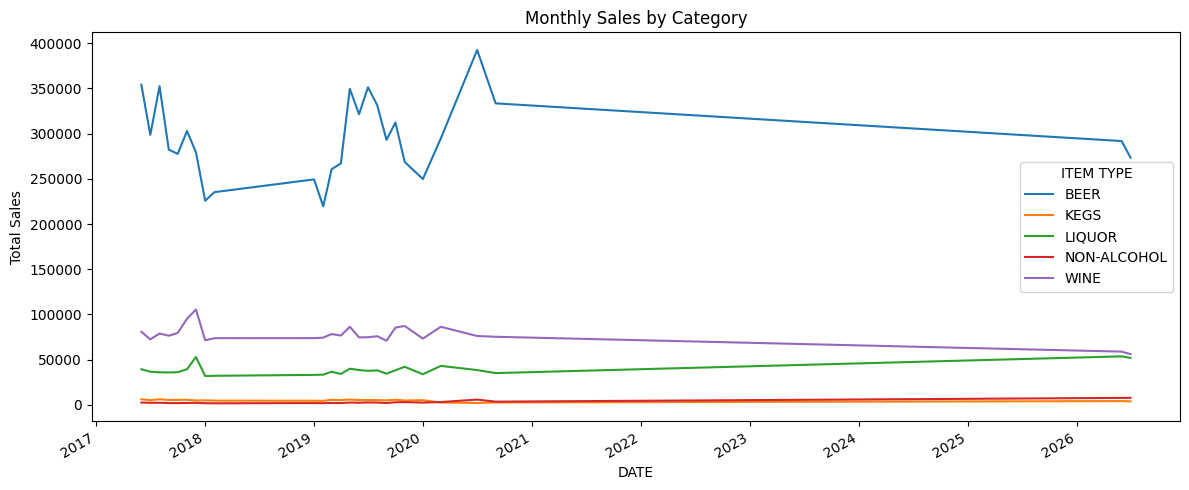

In [11]:
category_monthly = df.groupby(["DATE", "ITEM TYPE"])["TOTAL SALES"].sum().unstack().fillna(0)
category_monthly.plot(figsize=(12, 5), title="Monthly Sales by Category")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.savefig("eda_category_trend.png")
plt.show()


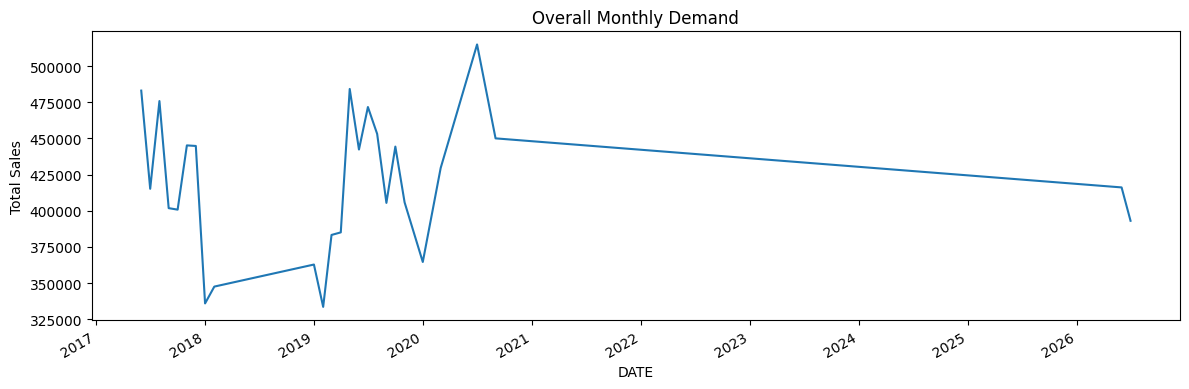

In [12]:
overall = df.groupby("DATE")["TOTAL SALES"].sum()
overall.plot(figsize=(12, 4), title="Overall Monthly Demand")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.savefig("eda_overall_trend.png")
plt.show()


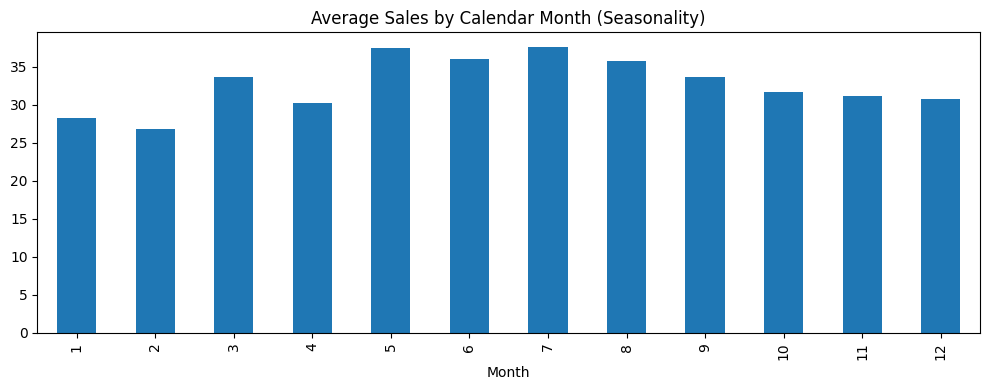

In [13]:
monthly_seasonality = df.groupby(df["DATE"].dt.month)["TOTAL SALES"].mean()
monthly_seasonality.plot(kind="bar", figsize=(10, 4), title="Average Sales by Calendar Month (Seasonality)")
plt.xlabel("Month")
plt.tight_layout()
plt.savefig("eda_seasonality.png")
plt.show()


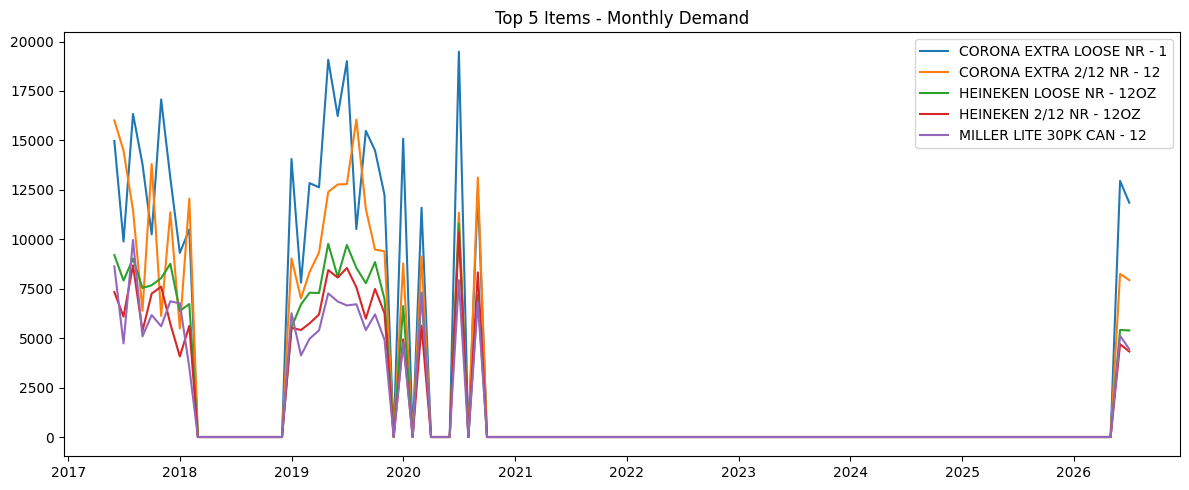

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))
for code_ in top_items[:5]:
    ax.plot(series_dict[code_].index, series_dict[code_].values, label=item_names[code_][:25])
ax.legend()
ax.set_title("Top 5 Items - Monthly Demand")
plt.tight_layout()
plt.savefig("eda_top_items.png")
plt.show()


In [15]:
zero_pct = {c: (series_dict[c] == 0).mean() for c in top_items}
pd.Series(zero_pct, name="pct_zero_months").sort_values(ascending=False)


23445    0.763636
96750    0.763636
23886    0.763636
96970    0.763636
90590    0.763636
96741    0.763636
25883    0.763636
95800    0.763636
90468    0.763636
23777    0.763636
96083    0.763636
99198    0.763636
23314    0.763636
91170    0.763636
23318    0.763636
Name: pct_zero_months, dtype: float64

## 5. Feature Engineering

In [16]:
def make_features(s):
    d = pd.DataFrame({"y": s})
    d["month"] = d.index.month
    d["quarter"] = d.index.quarter
    d["lag_1"] = d["y"].shift(1)
    d["lag_2"] = d["y"].shift(2)
    d["lag_3"] = d["y"].shift(3)
    d["lag_12"] = d["y"].shift(12)
    d["rolling_mean_3"] = d["y"].shift(1).rolling(3).mean()
    d["rolling_mean_6"] = d["y"].shift(1).rolling(6).mean()
    d["rolling_std_3"] = d["y"].shift(1).rolling(3).std()
    return d

features_dict = {c: make_features(series_dict[c]) for c in top_items}
features_dict[top_items[0]].tail()


,y,month,quarter,lag_1,lag_2,lag_3,lag_12,rolling_mean_3,rolling_mean_6,rolling_std_3
2026-03-01,0.00,3,1,0.00,0.0,0.0,0.0,0.000000,0.000000,0.000000
2026-04-01,0.00,4,2,0.00,0.0,0.0,0.0,0.000000,0.000000,0.000000
2026-05-01,0.00,5,2,0.00,0.0,0.0,0.0,0.000000,0.000000,0.000000
2026-06-01,12952.88,6,2,0.00,0.0,0.0,0.0,0.000000,0.000000,0.000000
2026-07-01,11850.96,7,3,12952.88,0.0,0.0,0.0,4317.626667,2158.813333,7478.348755


## 6. Train/Test Split

In [17]:
TEST_MONTHS = 6

train_dict, test_dict = {}, {}
for c in top_items:
    s = series_dict[c]
    train_dict[c] = s.iloc[:-TEST_MONTHS]
    test_dict[c] = s.iloc[-TEST_MONTHS:]


## 7. Forecasting Models

In [18]:
def naive_seasonal_forecast(train, horizon, season=12):
    if len(train) >= season:
        last_season = train.iloc[-season:]
        reps = int(np.ceil(horizon / season))
        return np.tile(last_season.values, reps)[:horizon]
    return np.repeat(train.iloc[-1], horizon)

def holt_winters_forecast(train, horizon, season=12):
    try:
        model = ExponentialSmoothing(
            train, trend="add", seasonal="add", seasonal_periods=season,
            initialization_method="estimated"
        ).fit(optimized=True)
        return model.forecast(horizon).values
    except Exception:
        return naive_seasonal_forecast(train, horizon, season)

def sarima_forecast(train, horizon, order=(1,1,1), seasonal_order=(1,1,1,12)):
    try:
        model = SARIMAX(
            train, order=order, seasonal_order=seasonal_order,
            enforce_stationarity=False, enforce_invertibility=False
        ).fit(disp=False)
        return model.forecast(horizon).values
    except Exception:
        return naive_seasonal_forecast(train, horizon)


In [19]:
results = []
forecast_records = []

for c in top_items:
    train, test = train_dict[c], test_dict[c]
    horizon = len(test)

    preds = {
        "Naive Seasonal": naive_seasonal_forecast(train, horizon),
        "Holt-Winters": holt_winters_forecast(train, horizon),
        "SARIMA": sarima_forecast(train, horizon),
    }

    for model_name, pred in preds.items():
        pred = np.clip(pred, 0, None)
        mae = mean_absolute_error(test.values, pred)
        rmse = np.sqrt(mean_squared_error(test.values, pred))
        denom = np.where(test.values == 0, 1, test.values)
        mape = np.mean(np.abs((test.values - pred) / denom)) * 100

        results.append({
            "ITEM CODE": c, "ITEM DESCRIPTION": item_names[c], "MODEL": model_name,
            "MAE": mae, "RMSE": rmse, "MAPE": mape
        })

        for date_, actual_, pred_ in zip(test.index, test.values, pred):
            forecast_records.append({
                "ITEM CODE": c, "ITEM DESCRIPTION": item_names[c], "MODEL": model_name,
                "DATE": date_, "ACTUAL": actual_, "FORECAST": pred_
            })

results_df = pd.DataFrame(results)
forecast_df = pd.DataFrame(forecast_records)
results_df.sort_values(["ITEM CODE", "MAE"])


,ITEM CODE,ITEM DESCRIPTION,MODEL,MAE,RMSE,MAPE
37,23314,CORONA EXTRA 18PK NR - 12OZ,Holt-Winters,988.353556,1715.778984,32.409699
38,23314,CORONA EXTRA 18PK NR - 12OZ,SARIMA,1003.572049,1732.492444,526.466676
36,23314,CORONA EXTRA 18PK NR - 12OZ,Naive Seasonal,1015.388333,1760.049384,33.333333
42,23318,MODELO ESPECIAL 18PK CAN - 12OZ,Naive Seasonal,1580.843333,2832.280372,33.333333
44,23318,MODELO ESPECIAL 18PK CAN - 12OZ,SARIMA,1591.184995,2832.393653,1067.499541
43,23318,MODELO ESPECIAL 18PK CAN - 12OZ,Holt-Winters,1592.171890,2819.464267,1787.314851
2,23445,CORONA EXTRA LOOSE NR - 12OZ,SARIMA,3860.967312,6713.448081,31.071125
1,23445,CORONA EXTRA LOOSE NR - 12OZ,Holt-Winters,3966.104648,6896.423814,31.916835
0,23445,CORONA EXTRA LOOSE NR - 12OZ,Naive Seasonal,4133.973333,7167.314155,33.333333
28,23777,MODELO ESPECIAL SUITCASE CANS - 12OZ,Holt-Winters,2894.997387,5001.715471,921.953177


## 8. Evaluation Summary

In [20]:
summary = results_df.groupby("MODEL")[["MAE", "RMSE", "MAPE"]].mean().sort_values("MAPE")
print(summary)

best_model = summary["MAPE"].idxmin()
print("\nBest performing model overall:", best_model)


                        MAE         RMSE         MAPE
MODEL                                                
Naive Seasonal  1956.088222  3397.403010    33.333333
Holt-Winters    1880.712529  3268.743998   351.007369
SARIMA          1879.202307  3245.749473  1404.499942

Best performing model overall: Naive Seasonal


In [21]:
best_per_item = results_df.loc[results_df.groupby("ITEM CODE")["MAPE"].idxmin()]
best_per_item[["ITEM CODE", "ITEM DESCRIPTION", "MODEL", "MAE", "RMSE", "MAPE"]]


,ITEM CODE,ITEM DESCRIPTION,MODEL,MAE,RMSE,MAPE
37,23314,CORONA EXTRA 18PK NR - 12OZ,Holt-Winters,988.353556,1715.778984,32.409699
42,23318,MODELO ESPECIAL 18PK CAN - 12OZ,Naive Seasonal,1580.843333,2832.280372,33.333333
2,23445,CORONA EXTRA LOOSE NR - 12OZ,SARIMA,3860.967312,6713.448081,31.071125
27,23777,MODELO ESPECIAL SUITCASE CANS - 12OZ,Naive Seasonal,2989.133333,5177.342970,33.333333
7,23886,HEINEKEN LOOSE NR - 12OZ,Holt-Winters,1699.997249,2950.014608,31.469368
19,25883,MODELO ESPECIAL 24 LOOSE NR - 12OZ,Holt-Winters,2548.586335,4422.619214,31.882332
26,90468,BUD LIGHT 30PK CAN,SARIMA,678.019149,1177.888358,32.233059
12,90590,MILLER LITE 30PK CAN - 12OZ,Naive Seasonal,1595.145000,2769.813728,33.333333
39,91170,COORS LT 30PK CAN - 12OZ,Naive Seasonal,1193.966667,2073.281812,33.333333
21,95800,MODELO ESPECIAL-2/12 CAN - 12OZ,Naive Seasonal,3327.480000,5780.264237,33.333333


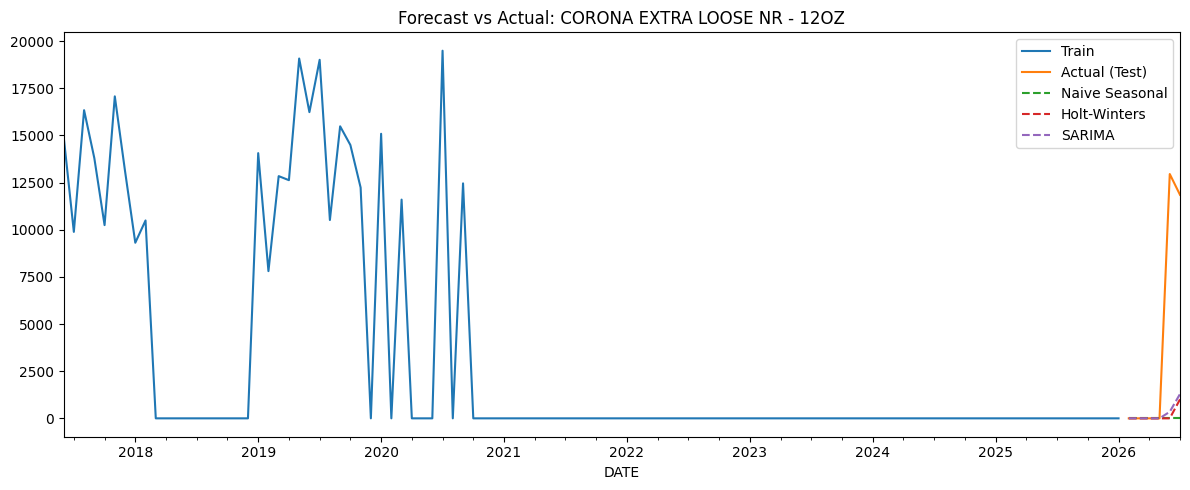

In [22]:
fig, ax = plt.subplots(figsize=(12, 5))
sample_item = top_items[0]
train_dict[sample_item].plot(ax=ax, label="Train")
test_dict[sample_item].plot(ax=ax, label="Actual (Test)")
sub = forecast_df[(forecast_df["ITEM CODE"] == sample_item)]
for m in sub["MODEL"].unique():
    s = sub[sub["MODEL"] == m].set_index("DATE")["FORECAST"]
    s.plot(ax=ax, label=m, linestyle="--")
ax.legend()
ax.set_title(f"Forecast vs Actual: {item_names[sample_item]}")
plt.tight_layout()
plt.savefig("forecast_vs_actual_sample.png")
plt.show()


## 9. Export Results for Power BI

In [23]:
df.to_csv("cleaned_warehouse_retail_sales.csv", index=False)

item_monthly.to_csv("item_monthly_demand.csv", index=False)

results_df.to_csv("model_evaluation_results.csv", index=False)

forecast_df.to_csv("forecast_vs_actual.csv", index=False)

category_summary = df.groupby(["DATE", "ITEM TYPE"], as_index=False)["TOTAL SALES"].sum()
category_summary.to_csv("category_monthly_summary.csv", index=False)

print("Exported files:")
print("- cleaned_warehouse_retail_sales.csv")
print("- item_monthly_demand.csv")
print("- model_evaluation_results.csv")
print("- forecast_vs_actual.csv")
print("- category_monthly_summary.csv")


Exported files:
- cleaned_warehouse_retail_sales.csv
- item_monthly_demand.csv
- model_evaluation_results.csv
- forecast_vs_actual.csv
- category_monthly_summary.csv
